## lets focus on this token for now. the reference is often called the query

# Simple self attention


In [1]:
import torch


In [2]:
inputs = torch.tensor(
    [[0.43,0.15,0.89], #your
     [0.55,0.87,0.66],#journey
     [0.57,0.85,0.64],#starts
     [0.22,0.58,0.33],
     [0.77,0.25,0.10],
     [0.05,0.80,0.55]]
)

In [3]:
#finding similarity between vectors
input_query = inputs[1]
input_query


tensor([0.5500, 0.8700, 0.6600])

In [4]:
input_1= inputs[0]
input_1


tensor([0.4300, 0.1500, 0.8900])

In [5]:
0.55*0.43 + 0.87*0.15 + 0.66*0.89    #dot project

0.9544

In [6]:
torch.dot(input_query, input_1)

tensor(0.9544)

In [7]:
for idx,ele in enumerate(inputs[0]):
    print(inputs[0][idx]) 

tensor(0.4300)
tensor(0.1500)
tensor(0.8900)


In [8]:
res=0.

# using enumerate now we can track the input_query indices also.
for idx,ele in enumerate(inputs[0]):   
    res += inputs[0][idx]*input_query[idx]   # this is the enumerate trick we are using to keep track



print(res)

tensor(0.9544)


In [9]:
    # better way is to use this dot product function
i=3
res= torch.dot(inputs[i], input_query)
res

tensor(0.8434)

In [10]:
torch.empty(inputs.shape[0])

tensor([6.3352e+26, 2.1328e-42, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00])

In [11]:
print(inputs.shape)

torch.Size([6, 3])


In [12]:
# query = input[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    # print(x_i)
    attn_scores_2[i] = torch.dot(x_i, input_query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


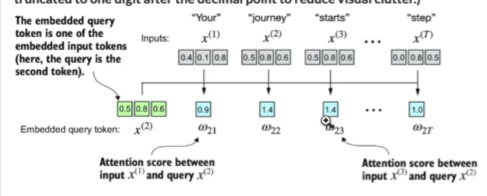
the above values are these w21, w22 etc

and now we'll normalise them

## normalise

In [13]:
attn_weight_2_tmp= attn_scores_2/ attn_scores_2.sum()

In [14]:
attn_weight_2_tmp.sum()

tensor(1.0000)

but more common way is to use softmax.


just to illustrate we are using e^.

In [15]:
def softmax_naive(x):
    return torch.exp(x)/ torch.exp(x).sum(dim=0)



In [16]:
l= torch.tensor([[2,3,4]])
print(l.shape)
l.sum(dim=0)

torch.Size([1, 3])


tensor([2, 3, 4])

In [17]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)   # using preimplemented fucntions is better

In [18]:
torch.zeros(input_query.shape)

tensor([0., 0., 0.])

In [19]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


simple self attention: without tranable weights

In [20]:
# we have found the context vector of only 1 word, now we have to find for all!
context_matrix = torch.zeros(inputs.shape)
print(context_matrix)

attn_wts= torch.zeros(inputs.shape)
attn_wts_soft= torch.zeros(inputs.shape)
print(attn_wts)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [21]:
# this is my trial

# for i, query in enumerate(inputs):
#     # now we are focussing on first query
#     for key in inputs:
#         attn_wts[i] = torch.dot(query,key) 
#         # print(i,query, key, attn_wts[i])
#         # now lets normalise also
#         attn_wts_soft[i]= torch.softmax(attn_wts[i], dim=0) 
#         # print(i, attn_wts_soft)
#         # now lets find the context vector, for this, now we'll have to multiply 
#         # this vector with the input matrix
#         print(attn_wts_soft[i])
# print(inputs)
# print(attn_wts_soft)
# print(inputs.shape)
# print(inputs.T.shape)
# print(attn_wts_soft.shape)
# context_matrix = attn_wts_soft @ inputs.T

# print(context_matrix)




In [22]:
attn_scores = torch.empty(6,6)

for i , x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i,j] = torch.dot(x_i, x_j)

print(attn_scores)


tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


### for loops aren't optimised, but MATRIX MULTIPLICATIONS ARE

In [23]:
attn_scores = inputs @ inputs.T
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In [24]:
attn_weights = torch.softmax(attn_scores,dim =1)
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [25]:
attn_weights.sum(dim=1)


tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [26]:
print(attn_weights.sum(dim=1).shape)


torch.Size([6])


In [27]:
print(attn_weights.shape, inputs.shape)

torch.Size([6, 6]) torch.Size([6, 3])


In [28]:
all_context_vecs = attn_weights @ inputs
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

# self attn with traninable wts- q k v
### one step closer

In [29]:
x_2 = inputs[1]

d_in= inputs.shape[1]   #oh man, this is the number of columns, not the tensor dimension
print(d_in)

d_out= 2    # d----> dimension

x_2

3


tensor([0.5500, 0.8700, 0.6600])

In [30]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand((d_in, d_out)))     #Parameter make this traninable
# later we'll replace this "parameter" with something else,but for now its fine
W_key = torch.nn.Parameter(torch.rand((d_in, d_out))) 
W_value = torch.nn.Parameter(torch.rand((d_in, d_out)))   
W_query
# we'll do traning in ch5

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]], requires_grad=True)

In [31]:
W_value

Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]], requires_grad=True)

In [32]:
query_2 = x_2 @ W_value
query_2

tensor([0.3951, 1.0037], grad_fn=<SqueezeBackward4>)

In [33]:
keys= inputs @ W_key

keys.shape


torch.Size([6, 2])

In [34]:
keys

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]], grad_fn=<MmBackward0>)

In [35]:
keys_2 = keys[1]
attn_score_22= torch.dot( query_2, keys_2) 
keys_2.shape


torch.Size([2])

In [36]:
query_2

tensor([0.3951, 1.0037], grad_fn=<SqueezeBackward4>)

In [37]:
# now again,using short way to do the same thing
attn_scores_2= query_2 @ keys_2.T
attn_scores_2

C:\Users\nisha\AppData\Local\Temp\ipykernel_4804\3704102051.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4483.)
  attn_scores_2= query_2 @ keys_2.T


tensor(1.3213, grad_fn=<DotBackward0>)

In [38]:
d_k= keys.shape[1]

torch.softmax(attn_scores_2/d_k**0.5, dim = -1)

tensor(1., grad_fn=<SoftmaxBackward0>)

i have done some error, i am leaving this here, and will implement the full version on my own later


In [39]:
# lets generalise so that at once we do everything! wow!(well just as what we did before)
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [40]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        
        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


using linear layer we get better results than nn.Parameter.

It is simply a well-engineered PyTorch wrapper around the same matrix multiplication (plus optional bias) that makes training and implementation easier.

In [41]:
class SelfAttention_v2(nn.Module):
# we are disabling the bias- modern llms disable this
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


## mask

In [42]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [43]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.2098, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1385, 0.2379, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1390, 0.2369, 0.2326, 0.0000, 0.0000, 0.0000],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.0000, 0.0000],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.0000],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


However, if the mask were applied after softmax, like above, it would disrupt the probability distribution created by softmax
Softmax ensures that all output values sum to 1
Masking after softmax would require re-normalizing the outputs to sum to 1 again, which complicates the process and might lead to unintended effects
To make sure that the rows sum to 1, we can normalize the attention weights as follows:

In [44]:

row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3680, 0.6320, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2284, 0.3893, 0.3822, 0.0000, 0.0000, 0.0000],
        [0.2046, 0.2956, 0.2915, 0.2084, 0.0000, 0.0000],
        [0.1753, 0.2250, 0.2269, 0.1570, 0.2158, 0.0000],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [45]:
# drop not used now a days- we are doing only for completeness
torch.manual_seed(123)
layer = torch.nn.Dropout(0.5)

In [46]:
# toy example
example = torch.ones(6,6)
example

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

In [47]:
layer(example)

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

some numbers are larger because it tries to keep the sum same( this is a small example so it dont turn out exact)

In [48]:
dropout_rate= 0.5
1/(1 - dropout_rate)  # this is the formula for rescaling the values

2.0

In [49]:
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [50]:
layer(attn_weights)

tensor([[0.4197, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4665, 0.0000, 0.2164, 0.3162],
        [0.0000, 0.4738, 0.4652, 0.2484, 0.2216, 0.3129],
        [0.0000, 0.0000, 0.4091, 0.2924, 0.0000, 0.3441],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3757, 0.2590],
        [0.2769, 0.4367, 0.0000, 0.2841, 0.1976, 0.3791]])

## implementing a compact causal self attn class


In [51]:
inputs.shape

torch.Size([6, 3])

In [52]:
batch= torch.stack((inputs, inputs), dim =0)
batch

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

In [53]:
class Causal_Attention(nn.Module):
# we are disabling the bias- modern llms disable this
    def __init__(self, d_in, d_out,context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b,num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.transpose(-2,-1)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(
            attn_scores/keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec 

torch.manual_seed(789)
dropout= 0.0
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


let me code myself the causal attention

In [54]:
import torch
class CausalAttention(torch.nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias= False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias= qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias= qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias= qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=-1)
        )

    def forward(self,x):
        b, num_tokens, d_in = x.shape
        keys= self.W.key(x)
        queries= self.W_query(x)
        values= self.W_value(x)
# what is this x, why are we passing it here... 
        attn_scores = queries @ keys.transpose(1,2)
        # why not transpose -1,-2
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens],-torch.inf) 
        # how is this [:num tokens] working.
        # i just know that we are increasing the size of the mask everytime

        attn_weights= torch.softmax(
            attn_scores/keys.shape[-1]**0.5, dim=-1
        )
        # well we could have taken queries also na
        attn_weights= self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec


now lets come to multi head attention

# naive version


In [55]:
# just run this causal attention many times
class MultiHeadAttentionWrapper(torch.nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias= False):
        super().__init()
        self.heads= torch.nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
                             for _ in range(num_heads)]
        )

    def forward(self,x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

# lets do the big boy stuff!

In [ ]:
import torch
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias= False):
        super().__init__()
        assert( d_out % num_heads == 0), \
        "dout must be divisible by num_heads"

# din is the input dimension ie the number of columns....now this d_out is the dimension of the query... our wish we want what dimension
# why no self.d_in... may be i should revise oops
        self.d_out = d_out
        self.num_heads= num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias= qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias= qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias= qkv_bias)
        self.out_proj = nn.Linear(d_out, d_in)
        self.dropout=  nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), 
                               diagonal=1)
        )


    def forward(self,x):
        print("HARE KRISHNA")
        b, num_tokens, d_in = x.shape   #b->batch
        keys= self.W_key(x)
        queries= self.W_query(x)
        values = self.W_value(x)

    #     now the dim of key,q, v is (d_in, d_out)
        queries= queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        keys= keys.transpose(1,2)
        queries= queries.transpose(1,2)
        values = values.transpose(1,2)

        attn_scores= queries @ keys.transpose(-2,-1)
        # now mask 
        mask_bool= self.mask.bool()[:num_tokens , : num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim= -1)
        
        print("queries", queries.shape)
        print("keys", keys.shape)
        print("values", values.shape)
        print("attn_scores", attn_scores.shape)
        print("mask_bool", mask_bool.shape)
        
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1,2)

        context_vec = context_vec.contiguous().view(b,num_tokens, self.d_out)

        context_vec= self.out_proj(context_vec)

        return context_vec



In [57]:
print(MultiHeadAttention.forward)

<function MultiHeadAttention.forward at 0x000001FD836F2200>
